In [1]:
import requests
import pandas as pd
from datetime import datetime

## Identifiants STRAVA

In [2]:
CLIENT_ID = "223002"
CLIENT_SECRET = "39dd692c823258c9b233caf20e10808f814417a4"
REFRESH_TOKEN = "e42ec030c1b951262af65261afcc03b14376758b"

In [5]:
# curl -X POST https://www.strava.com/api/v3/oauth/token \
#   -d client_id=223002 \
#   -d client_secret=39dd692c823258c9b233caf20e10808f814417a4 \
#   -d code=c4ef0213d5ed1febc5f0cb69d66dc5bed672d5d6 \
#   -d grant_type=authorization_code

In [6]:
# {"token_type":"Bearer","expires_at":1775827234,"expires_in":21600,"refresh_token":"e42ec030c1b951262af65261afcc03b14376758b","access_token":"dd0b1e80e4d59480ed03ad1fc2652ae933e82631","athlete":{"id":103224028,"username":null,"resource_state":2,"firstname":"Christel","lastname":"Domange","bio":null,"city":"","state":"","country":null,"sex":"F","premium":false,"summit":false,"created_at":"2022-05-17T15:58:41Z","updated_at":"2026-04-10T05:27:39Z","badge_type_id":0,"profile_medium":"avatar/athlete/medium.png","profile":"avatar/athlete/large.png","friend":null,"follower":null}}%     

In [7]:
# http://localhost/exchange_token?state=&code=c4ef0213d5ed1febc5f0cb69d66dc5bed672d5d6&scope=read,activity:read_all

## Access Token

In [8]:
def get_access_token():
    url = "https://www.strava.com/oauth/token"
    
    payload = {
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "refresh_token": REFRESH_TOKEN,
        "grant_type": "refresh_token"
    }
    
    response = requests.post(url, data=payload)
    response.raise_for_status()
    
    tokens = response.json()
    return tokens["access_token"]

In [9]:
access_token = get_access_token()
print(access_token[:20])

dd0b1e80e4d59480ed03


## Liste d'activités

In [10]:
def get_activities(access_token, per_page=50, page=1):
    url = "https://www.strava.com/api/v3/athlete/activities"
    
    headers = {
        "Authorization": f"Bearer {access_token}"
    }
    
    params = {
        "per_page": per_page,
        "page": page
    }

    response = requests.get(url, headers=headers, params=params)

    print(response.status_code)
    print(response.text)
    response.raise_for_status()
    
    return response.json()

In [11]:
activities = get_activities(access_token)
len(activities)

200
[{"resource_state":2,"athlete":{"id":103224028,"resource_state":1},"name":"Course à pied le matin","distance":4216.2,"moving_time":1634,"elapsed_time":1637,"total_elevation_gain":101.0,"type":"Run","sport_type":"Run","workout_type":null,"device_name":"Garmin Venu 2S","id":18036725196,"start_date":"2026-04-09T05:40:27Z","start_date_local":"2026-04-09T07:40:27Z","timezone":"(GMT+01:00) Europe/Paris","utc_offset":7200.0,"location_city":null,"location_state":null,"location_country":null,"achievement_count":0,"kudos_count":0,"comment_count":0,"athlete_count":1,"photo_count":0,"map":{"id":"a18036725196","summary_polyline":"opvvGwiu\\JHD?Fm@Ea@@w@Gs@KkB?a@Di@j@oBPoB\\mBRyAd@mBXo@Ha@L[Hi@h@yBLMLc@x@oEfAsC@a@C]@oAFY@qAImBMoAMp@CzA?dBGTKRC@YKMKGOEq@EIYMM?GCKDMAEDCACPGF?JIJG|@EZEJQAOGKQAWGQ@k@CY?gAC]Ie@MWOOOWGi@GOYY@e@GKK}@KOg@g@U@[A[IWOQ?UDCFR~BJtCJjAF^FdASqBYuFGq@QgAAQU{@SKWEG?[b@Kp@Bt@Hh@CTHjBP~BLp@HFLd@K`@SNc@Bk@JcAd@ULYXm@Zc@P_@Ve@l@{BrHSXORQJc@NeBNYV_@fBIv@IRMN}@x@_@VQ`@Gt@k@zD]vCg@hFBL

4

In [12]:
df = pd.json_normalize(activities)
df.head()

,resource_state,name,distance,moving_time,elapsed_time,total_elevation_gain,type,sport_type,workout_type,device_name,...,external_id,from_accepted_tag,pr_count,total_photo_count,has_kudoed,athlete.id,athlete.resource_state,map.id,map.summary_polyline,map.resource_state
0,2,Course à pied le matin,4216.2,1634,1637,101.0,Run,Run,None,Garmin Venu 2S,...,stripped_garmin_ping_556344408797,False,0,0,False,103224028,1,a18036725196,opvvGwiu\JHD?Fm@Ea@@w@Gs@KkB?a@Di@j@oBPoB\mBRy...,2
1,2,Course à pied en soirée,2680.4,953,961,31.0,Run,Run,None,Garmin Venu 2S,...,stripped_garmin_ping_555278338235,False,0,0,False,103224028,1,a18003431342,wcxvGsoo\NG^ATNNAXSfAc@`@[nAyAr@cA^s@nAiB^cANq...,2
2,2,Course à pied en soirée,4284.1,1489,1730,27.0,Run,Run,None,Garmin Venu 2S,...,stripped_garmin_ping_555278265342,False,0,0,False,103224028,1,a18003431571,wpvvG{iu\@FAOPh@BTGXSd@EcCDBHVR`@ATIVaA~BKb@Ej...,2
3,2,Course à pied le matin,10582.7,4652,5959,467.0,Run,Run,None,Garmin Venu 2S,...,stripped_garmin_ping_554337943360,False,0,0,False,103224028,1,a17972688601,{iwvGe{l\zBdB~DpDl@^EzA@fA@Hp@rANl@B`@@l@In@Dr...,2


In [13]:
print(df.columns)

Index(['resource_state', 'name', 'distance', 'moving_time', 'elapsed_time',
       'total_elevation_gain', 'type', 'sport_type', 'workout_type',
       'device_name', 'id', 'start_date', 'start_date_local', 'timezone',
       'utc_offset', 'location_city', 'location_state', 'location_country',
       'achievement_count', 'kudos_count', 'comment_count', 'athlete_count',
       'photo_count', 'trainer', 'commute', 'manual', 'private', 'visibility',
       'flagged', 'gear_id', 'start_latlng', 'end_latlng', 'average_speed',
       'max_speed', 'average_cadence', 'has_heartrate', 'heartrate_opt_out',
       'display_hide_heartrate_option', 'elev_high', 'elev_low', 'upload_id',
       'upload_id_str', 'external_id', 'from_accepted_tag', 'pr_count',
       'total_photo_count', 'has_kudoed', 'athlete.id',
       'athlete.resource_state', 'map.id', 'map.summary_polyline',
       'map.resource_state'],
      dtype='object')


In [14]:
# cols = [
#     "id",
#     "name",
#     "type",
#     "distance",
#     "moving_time",
#     "total_elevation_gain",
#     "start_date",
#     "average_speed",
#     "average_heartrate",
#     "map.summary_polyline"
# ]

# df[cols].head()

In [15]:
def get_activity_streams(activity_id, access_token):
    url = f"https://www.strava.com/api/v3/activities/{activity_id}/streams"
    
    headers = {
        "Authorization": f"Bearer {access_token}"
    }
    
    params = {
        "keys": "time,latlng,distance,altitude,heartrate,velocity_smooth",
        "key_by_type": "true"
    }
    
    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()
    
    return response.json()

In [16]:
tracks = []

for activity_id in df["id"]:
    streams = get_activity_streams(activity_id, access_token)

    # récupérer les coordonnées GPS
    coords = streams["latlng"]["data"]
    print(activity_id, coords[:5])  # aperçu des 5 premiers points

    track_df = pd.DataFrame(coords, columns=["lat", "lng"])
    track_df["activity_id"] = activity_id

    tracks.append(track_df)

tracks_df = pd.concat(tracks, ignore_index=True)

18036725196 [[45.831922, 4.865721], [45.831914, 4.865719], [45.831865, 4.865675], [45.831837, 4.865674], [45.831823, 4.865719]]
18003431342 [[45.840126, 4.835949], [45.840113, 4.83596], [45.840041, 4.835988], [45.839885, 4.835994], [45.839795, 4.835935]]
18003431571 [[45.831963, 4.865747], [45.83196, 4.865731], [45.831957, 4.865709], [45.831969, 4.865781], [45.831973, 4.865779]]
17972688601 [[45.835981, 4.822433], [45.835981, 4.822433], [45.835981, 4.822433], [45.835981, 4.822433], [45.835981, 4.822433]]


In [17]:
track_df = pd.DataFrame(coords, columns=["lat", "lng"])
track_df["altitude"] = streams["altitude"]["data"]
track_df["distance"] = streams["distance"]["data"]
track_df["time"] = streams["time"]["data"]

track_df

,lat,lng,altitude,distance,time
0,45.835981,4.822433,205.8,0.0,0
1,45.835981,4.822433,205.8,2.2,1
2,45.835981,4.822433,205.4,24.6,9
3,45.835981,4.822433,205.4,35.8,13
4,45.835981,4.822433,205.6,39.0,14
...,...,...,...,...,...
1530,45.837073,4.823043,220.2,10562.3,5954
1531,45.837018,4.823005,220.2,10569.0,5956
1532,45.836986,4.823006,220.2,10572.6,5957
1533,45.836920,4.822959,220.2,10580.8,5960


In [18]:
import matplotlib.pyplot as plt

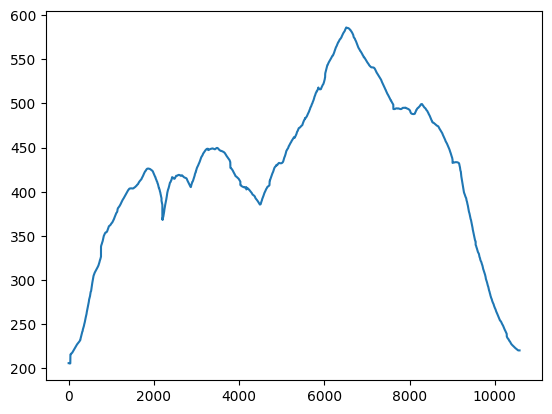

In [25]:
plt.plot( track_df['distance'],track_df['altitude'])